# Chronoamperometry & The Cottrell Equation: From Electrochemistry to Numerical PDEs

In electrochemical research, **chronoamperometry** is one of the most widely used transient techniques: a potential step is applied to a working electrode, driving a redox reaction under diffusion control, and the resulting current transient is recorded over time. For a planar macroelectrode, this current follows the classic **Cottrell equation** (Frederick Gardner Cottrell, 1902).

While electrochemists know the Cottrell equation as an analytical formula, it is fundamentally the exact solution to a **parabolic Partial Differential Equation (PDE)**—specifically, 1D semi-infinite linear diffusion governed by **Fick's Second Law**.

In this tutorial, we bridge the gap between electrochemical intuition and numerical modeling using **Soft Potato**. We will learn:

1. **How to formulate electrochemical problems as PDEs**: Translating the physical electrode surface and bulk reservoir into mathematical Initial and Boundary Conditions.
2. **Current from surface gradients**: Connecting Fick's First Law and Faraday's Law to extract electrical current from simulated concentration profiles.
3. **The mass transfer coefficient $k_m(t)$**: Why $k_m$ is time-dependent for an unstirred planar macroelectrode, how it relates to the dynamic Nernst diffusion layer $\delta(t)$, and how it leads directly to the Cottrell decay.
4. **Baseline simulation**: Simulating a complete chronoamperogram with `scipy_ivp` (Radau stiff integrator), visualizing concentration profiles $c(x, t)$, current transients $I(t)$, and Cottrell plots ($I$ vs. $t^{-1/2}$).
5. **Numerical solver comparison**: Simulating the identical experiment across four numerical engines (`scipy_ivp`, `crank_nicolson`, `implicit`, `explicit`) to investigate key numerical challenges:
   - **Numerical stability & the CFL barrier** for explicit methods.
   - **Step discontinuities at $t=0$ & Crank-Nicolson oscillations** (the Rannacher effect).
   - **Computational efficiency & execution time benchmarking**.
6. **Rigorous error analysis**: Quantifying numerical accuracy and spatial convergence rates against the exact Cottrell analytical solution.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf

import softpotato as sp
from softpotato.solver import (
    DiffusionProblem,
    DirichletBC,
    ExplicitFiniteDifference,
    get_solver,
    list_solvers,
)

# Publication-quality plotting defaults
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "lines.linewidth": 2.0,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Soft Potato Version: {sp.__version__}")
print(f"Available Solvers in Registry: {list_solvers()}")


Soft Potato Version: 3.0.0a1
Available Solvers in Registry: ['btcs', 'crank-nicolson', 'crank_nicolson', 'explicit', 'ftcs', 'implicit', 'scipy_ivp', 'solve_ivp']


---

## 1. Physical & Mathematical Formulation

### The Redox System
We consider the 1-electron anodic oxidation of a reduced species $\text{Red}$ at a planar working electrode:

$$\text{Red} \longrightarrow \text{Ox} + n e^-$$

In accordance with standard **IUPAC convention**, anodic (oxidation) currents are defined as **positive** ($I > 0$).

### Governing Equation: Fick's Second Law
Assuming excess supporting electrolyte (eliminating migration) and an unstirred solution (eliminating convection), transport of species $\text{Red}$ is governed purely by 1D linear diffusion perpendicular to the electrode surface:

$$\frac{\partial c_{\text{Red}}}{\partial t} = D_{\text{Red}} \frac{\partial^2 c_{\text{Red}}}{\partial x^2}$$

where:
- $x \ge 0$ is the distance from the electrode surface ($x = 0$ is the electrode, $x > 0$ is the electrolyte solution).
- $t \ge 0$ is the elapsed time since the potential step.
- $D_{\text{Red}}$ is the diffusion coefficient of the reactant ($\text{cm}^2/\text{s}$).
- $c_{\text{Red}}(x, t)$ is the local concentration ($\text{mol/cm}^3$ or $\text{mol/L}$).

---

### Translating Electrochemistry to Boundary and Initial Conditions

A Partial Differential Equation requires specific boundary conditions (spatial constraints) and initial conditions (temporal starting state) to define a unique physical solution:

1. **Initial Condition ($t = 0$)**:
   Before the potential step is applied, the electrochemical cell is at rest. The solution is completely homogeneous:
   $$c_{\text{Red}}(x, 0) = c^* \quad \text{for all } x \ge 0$$
   where $c^*$ is the bulk reactant concentration.

2. **Electrode Surface Boundary Condition ($x = 0, t > 0$)**:
   At $t = 0$, the electrode potential is stepped to a value sufficiently positive of the formal potential $E^{0'}$ so that the surface reaction is completely **diffusion-controlled** (mass-transfer-limited). Under this condition, the heterogeneous electron transfer rate is infinitely faster than mass transport, instantaneously consuming every molecule of $\text{Red}$ arriving at the surface:
   $$c_{\text{Red}}(0, t) = 0 \quad (\text{Dirichlet Boundary Condition: complete consumption})$$

3. **Infinite Bulk Boundary Condition ($x \to \infty, t > 0$)**:
   Real electrochemical cells have macroscopic liquid volumes (e.g. 5–50 mL). Over typical experimental timescales ($t \sim 0.1 - 5\text{ s}$), diffusion only penetrates a tiny fraction of a millimeter into the solution. Far away from the electrode, the solution remains completely unperturbed:
   $$c_{\text{Red}}(\infty, t) = c^* \quad (\text{Dirichlet Boundary Condition: bulk reservoir})$$

---

### Domain Truncation: Sizing the Simulation Box
Computers cannot solve equations on an infinitely long spatial domain ($x \in [0, \infty)$). We must truncate the domain to a finite simulation box $x \in [0, L]$.

*How large must the domain length $L$ be?*

Einstein's diffusion relation shows that the characteristic diffusion penetration depth after duration $t_{\text{max}}$ is:

$$\delta_{\text{penetration}} \approx 6 \sqrt{D t_{\text{max}}}$$

At $x = 6\sqrt{D t_{\text{max}}}$, the concentration perturbation is less than $0.1\%$ ($c_{\text{Red}} > 0.999 c^*$). Therefore, if we select:

$$L \ge 6 \sqrt{D t_{\text{max}}}$$

and impose the Dirichlet condition $c_{\text{Red}}(L, t) = c^*$, the outer boundary behaves as a true semi-infinite reservoir, introducing zero artificial boundary reflection errors into the simulation.


---

## 2. Obtaining the Current & The Mass Transfer Coefficient $k_m(t)$

### From Spatial Concentration Gradient to Electrical Current
Fick's First Law describes the diffusive molar flux along the coordinate axis $x$:

$$J_x(0, t) = -D_{\text{Red}} \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$$

Because species $\text{Red}$ is depleted at the electrode ($c_{\text{Red}}(0, t) = 0$) and increases toward the bulk, the spatial gradient is positive ($\left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} > 0$). Consequently, the flux vector $J_x$ is negative, indicating mass flow in the $-x$ direction (toward the electrode).

The molar flux of reactant entering the electrode is therefore:

$$J_{\text{in}}(t) = -J_x(0, t) = D_{\text{Red}} \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$$

By **Faraday's Law**, each mole of $\text{Red}$ that reaches the electrode and undergoes oxidation transfers $n$ moles of electrons into the electrode circuit, generating a positive anodic current:

$$I(t) = + n F A J_{\text{in}}(t) = n F A D_{\text{Red}} \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$$

where:
- $n$: stoichiometric number of electrons transferred (e.g. $n = 1$).
- $F$: Faraday's constant ($96485.33\text{ C/mol}$).
- $A$: electrode geometric surface area ($\text{cm}^2$).
- $D_{\text{Red}}$: diffusion coefficient ($\text{cm}^2/\text{s}$).
- $\left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0}$: concentration gradient at the electrode surface ($\text{mol/cm}^4$).

In **Soft Potato**, the solver automatically post-processes the concentration field and evaluates the surface flux $J_x(0, t)$ using a high-order 2nd-order forward difference:

$$\left.\frac{\partial c}{\partial x}\right|_{x=0} \approx \frac{-3 c_0 + 4 c_1 - c_2}{2 \Delta x}$$

The result is accessible via `result.fluxes['Red']`. Hence, the oxidation current is simply:

$$I(t) = -n F A \cdot \text{result.fluxes}['Red']$$

---

### The Mass Transfer Coefficient $k_m(t)$ and the Cottrell Equation
In mass transport theory, interfacial flux is commonly formulated in terms of a **mass transfer coefficient** $k_m(t)$ (dimensions of velocity, $\text{cm/s}$) and the concentration driving force:

$$J_{\text{in}}(t) = k_m(t) \cdot \left[ c^* - c_{\text{Red}}(0, t) \right]$$

For complete diffusion-controlled consumption where $c_{\text{Red}}(0, t) = 0$:

$$J_{\text{in}}(t) = k_m(t) \cdot c^* \implies I(t) = n F A k_m(t) c^*$$

The analytical solution to Fick's Second Law for semi-infinite linear diffusion under potential-step conditions gives the exact concentration profile:

$$c_{\text{Red}}(x, t) = c^* \operatorname{erf}\left(\frac{x}{2\sqrt{D t}}\right)$$

Differentiating with respect to $x$ at $x = 0$ yields the celebrated **Cottrell equation**:

$$I_{\text{Cottrell}}(t) = \frac{n F A D^{1/2} c^*}{\sqrt{\pi t}}$$

Equating our mass-transfer expression to the Cottrell equation immediately reveals the time-dependent mass transfer coefficient:

$$k_m(t) = \sqrt{\frac{D}{\pi t}}$$

### Physical Insights for Electrochemists:
1. **Unstirred Macroelectrodes vs. Steady-State Electrodes (RDE & Microelectrodes)**:
   - In steady-state methods (such as a Rotating Disk Electrode or an ultramicroelectrode), forced convection or divergent 3D hemispherical diffusion halts the growth of the depletion zone. A fixed Nernst diffusion layer thickness $\delta_{\text{N}}$ is established, yielding a constant mass transfer coefficient $k_m = D / \delta_{\text{N}}$ and a time-independent steady-state current.
   - At an unstirred planar macroelectrode, there is neither convection nor radial divergence. The Nernst diffusion layer thickness $\delta(t) = \sqrt{\pi D t}$ grows continuously into the solution without bound.
   - As $\delta(t)$ thickens, molecules must diffuse across greater distances, slowing down mass transport. Hence, $k_m(t) = D / \delta(t) \propto t^{-1/2}$ decays continuously over time.

2. **The $t = 0$ Singularity**:
   - As $t \to 0$, $\delta(t) \to 0$, which causes $k_m(t) \to \infty$ and $I(t) \to \infty$.
   - *Physical reality*: In a laboratory experiment, current never reaches infinity. The finite double-layer capacitance $C_{\text{dl}}$ and uncompensated solution resistance $R_u$ establish a cell time constant $\tau = R_u C_{\text{dl}}$ that limits early-time current.
   - *Numerical implication*: In numerical PDE simulations, the step jump between $c(x>0, 0)=c^*$ and $c(0, 0^+)=0$ represents an infinite gradient at $t=0$, presenting a sharp test for numerical ODE/PDE integrators.


In [2]:
# 1. Physical constants and experimental parameters
F = 96485.332      # Faraday constant (C / mol)
n = 1              # Number of electrons transferred
r_electrode = 0.15 # Radius of working electrode (cm) -> 3.0 mm diameter disc
A = np.pi * r_electrode**2  # Geometric electrode area (0.07069 cm²)

D = 1.0e-5         # Diffusion coefficient (cm²/s) -> e.g. [Fe(CN)6]4- in aqueous 0.1 M KCl
c_bulk_mM = 1.0    # Bulk concentration in mM (mmol / L)
c_bulk = c_bulk_mM * 1.0e-6  # Convert to mol / cm³ (1.0e-6 mol/cm³)

t_start = 0.0      # Start time (s)
t_end = 2.0        # Duration of potential step (s)

# 2. Domain sizing based on diffusion penetration depth
delta_penetration = 6.0 * np.sqrt(D * t_end)  # ~ 0.0268 cm (268 um)
L = 0.05  # Domain length = 500 um (safely greater than 268 um)

# 3. Spatial discretization
Nx = 251  # Number of grid points
x = np.linspace(0.0, L, Nx)
dx = x[1] - x[0]

print("=== Electrochemical Simulation Parameters ===")
print(f"Electrode Area (A):         {A:.5f} cm² (diameter = {2*r_electrode*10:.1f} mm)")
print(f"Diffusion Coefficient (D):   {D:.2e} cm²/s")
print(f"Bulk Concentration (c*):     {c_bulk_mM:.2f} mM ({c_bulk:.2e} mol/cm³)")
print(f"Max Penetration Depth:       {delta_penetration*1e4:.1f} µm")
print(f"Numerical Domain Length (L): {L*1e4:.1f} µm (L / delta = {L/delta_penetration:.2f})")
print(f"Spatial Grid Spacing (dx):   {dx*1e4:.2f} µm ({Nx} grid points)")

# 4. Formulate the DiffusionProblem in Soft Potato
problem = DiffusionProblem(
    grid=x,
    diffusivity={"Red": D},
    boundary_conditions={
        # Surface (x=0): complete consumption; Bulk (x=L): constant bulk concentration
        "Red": (DirichletBC(0.0), DirichletBC(c_bulk)),
    },
    initial_conditions={"Red": c_bulk},
)


=== Electrochemical Simulation Parameters ===
Electrode Area (A):         0.07069 cm² (diameter = 3.0 mm)
Diffusion Coefficient (D):   1.00e-05 cm²/s
Bulk Concentration (c*):     1.00 mM (1.00e-06 mol/cm³)
Max Penetration Depth:       268.3 µm
Numerical Domain Length (L): 500.0 µm (L / delta = 1.86)
Spatial Grid Spacing (dx):   2.00 µm (251 grid points)


In [3]:
# Evaluation time points: from t = 0 to 2.0 s (41 points, dt_eval = 0.05 s)
t_eval = np.linspace(t_start, t_end, 41)

# Baseline solver: Method of Lines using SciPy's stiff L-stable Radau ODE integrator
solver_radau = get_solver("scipy_ivp", method="Radau", rtol=1e-7, atol=1e-9)

t0 = time.perf_counter()
res_radau = solver_radau.solve(problem, t_span=(t_start, t_end), t_eval=t_eval)
solve_time_radau = (time.perf_counter() - t0) * 1000

print(f"Simulation completed: {res_radau.success}")
print(f"Solution array shape: {res_radau['Red'].shape} (time steps x spatial points)")
print(f"Execution time:       {solve_time_radau:.2f} ms")

# Extract numerical oxidation current in microamperes (uA):
# Recall: I(t) = -n * F * A * fluxes['Red']
I_num_radau_uA = -n * F * A * res_radau.fluxes["Red"] * 1e6

# Analytical Cottrell current for t > 0
times_nonzero = t_eval[1:]
I_cottrell_uA = (n * F * A * np.sqrt(D) * c_bulk / np.sqrt(np.pi * times_nonzero)) * 1e6

# Time-dependent mass transfer coefficient: k_m = I / (n * F * A * c_bulk)
km_num_radau = (I_num_radau_uA[1:] * 1e-6) / (n * F * A * c_bulk)
km_cottrell = np.sqrt(D / (np.pi * times_nonzero))


Simulation completed: True
Solution array shape: (41, 251) (time steps x spatial points)
Execution time:       190.64 ms


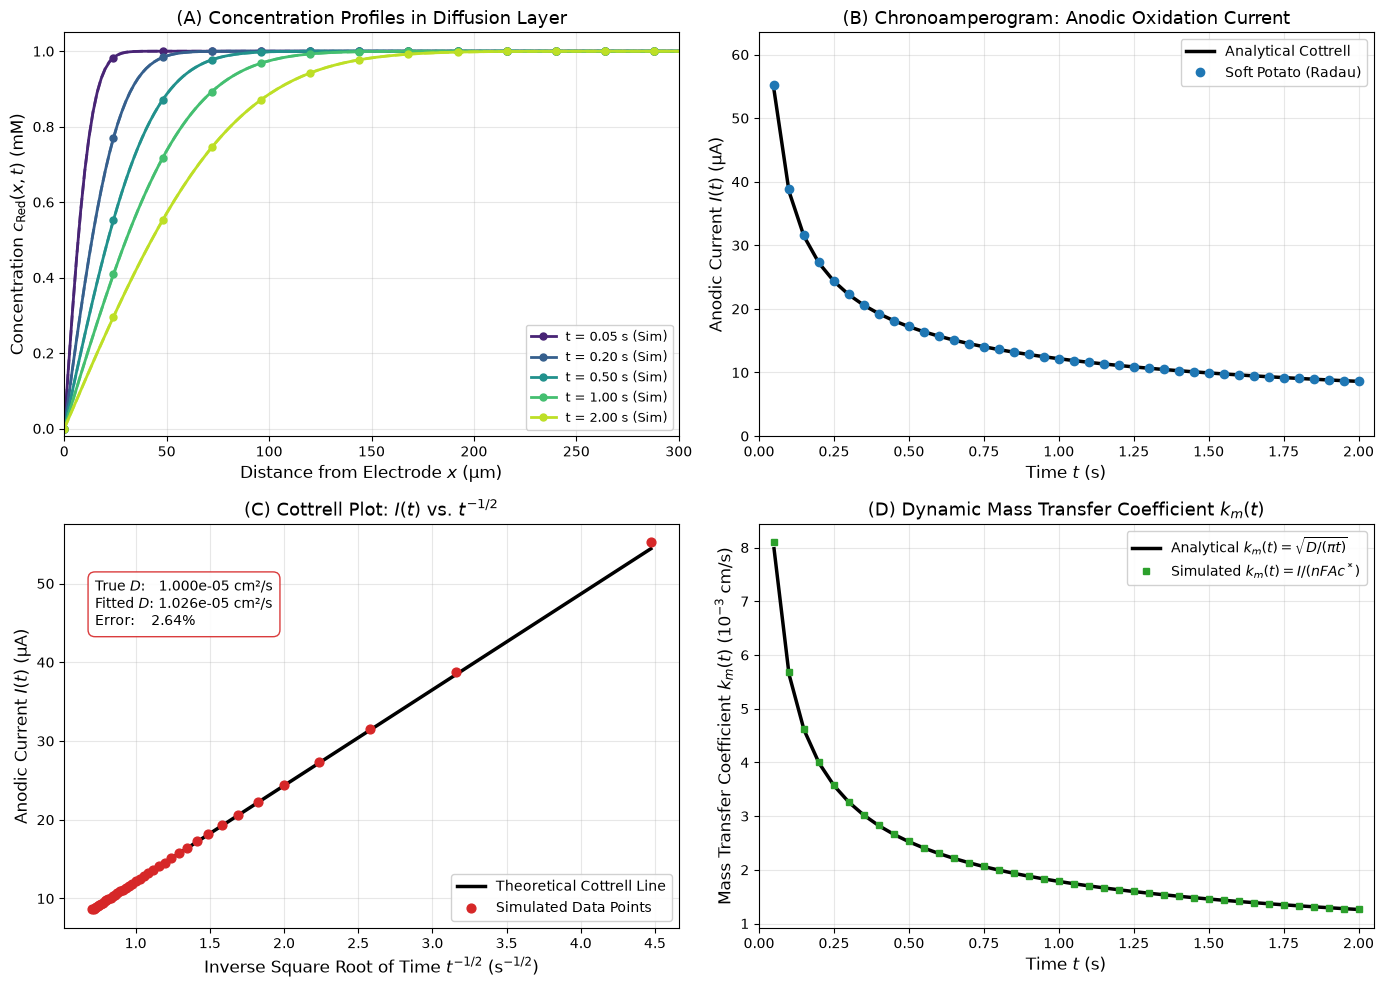

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel A: Concentration Profiles c(x, t) ---
ax_conc = axes[0, 0]
plot_times = [0.05, 0.2, 0.5, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(plot_times)))

for t_val, color in zip(plot_times, colors):
    idx = np.argmin(np.abs(t_eval - t_val))
    # Numerical profile (dots)
    ax_conc.plot(
        x * 1e4,
        res_radau["Red"][idx, :] * 1e6,  # convert to mM
        color=color,
        marker="o",
        markevery=12,
        markersize=5,
        label=f"t = {t_val:.2f} s (Sim)"
    )
    # Exact analytical profile: c(x, t) = c* * erf(x / (2*sqrt(D*t)))
    c_exact = c_bulk * erf(x / (2.0 * np.sqrt(D * t_val))) * 1e6
    ax_conc.plot(x * 1e4, c_exact, color=color, linestyle="--", alpha=0.8)

ax_conc.set_xlabel("Distance from Electrode $x$ (µm)")
ax_conc.set_ylabel(r"Concentration $c_{\mathrm{Red}}(x, t)$ (mM)")
ax_conc.set_title("(A) Concentration Profiles in Diffusion Layer")
ax_conc.set_xlim(0, 300)
ax_conc.set_ylim(-0.02, 1.05)
ax_conc.legend(loc="lower right", framealpha=0.9, fontsize=9)

# --- Panel B: Chronoamperogram I(t) ---
ax_ca = axes[0, 1]
ax_ca.plot(times_nonzero, I_cottrell_uA, "k-", lw=2.5, label="Analytical Cottrell")
ax_ca.plot(
    times_nonzero,
    I_num_radau_uA[1:],
    "o",
    color="#1f77b4",
    markersize=6,
    label="Soft Potato (Radau)"
)
ax_ca.set_xlabel("Time $t$ (s)")
ax_ca.set_ylabel("Anodic Current $I(t)$ (µA)")
ax_ca.set_title("(B) Chronoamperogram: Anodic Oxidation Current")
ax_ca.set_xlim(0, 2.05)
ax_ca.set_ylim(0, max(I_cottrell_uA[0], I_num_radau_uA[1]) * 1.15)
ax_ca.legend(framealpha=0.9)

# --- Panel C: Cottrell Plot I vs t^(-1/2) ---
ax_cot = axes[1, 0]
inv_sqrt_t = 1.0 / np.sqrt(times_nonzero)
ax_cot.plot(inv_sqrt_t, I_cottrell_uA, "k-", lw=2.5, label="Theoretical Cottrell Line")
ax_cot.scatter(
    inv_sqrt_t,
    I_num_radau_uA[1:],
    color="#d62728",
    s=40,
    zorder=4,
    label="Simulated Data Points"
)

# Linear regression to extract experimental diffusion coefficient
slope, intercept = np.polyfit(inv_sqrt_t, I_num_radau_uA[1:], 1)
# Slope = (n * F * A * c_bulk * sqrt(D_fit)) * 1e6 / sqrt(pi)
D_fitted = ((slope * 1e-6 * np.sqrt(np.pi)) / (n * F * A * c_bulk))**2

ax_cot.set_xlabel(r"Inverse Square Root of Time $t^{-1/2}$ ($\mathrm{s}^{-1/2}$)")
ax_cot.set_ylabel("Anodic Current $I(t)$ (µA)")
ax_cot.set_title(r"(C) Cottrell Plot: $I(t)$ vs. $t^{-1/2}$")
ax_cot.text(
    0.05,
    0.75,
    f"True $D$:   {D:.3e} cm²/s\nFitted $D$: {D_fitted:.3e} cm²/s\nError:    {abs(D_fitted - D)/D * 100:.2f}%",
    transform=ax_cot.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#d62728", alpha=0.9),
    fontsize=10
)
ax_cot.legend(loc="lower right", framealpha=0.9)

# --- Panel D: Mass Transfer Coefficient k_m(t) ---
ax_km = axes[1, 1]
ax_km.plot(times_nonzero, km_cottrell * 1e3, "k-", lw=2.5, label=r"Analytical $k_m(t) = \sqrt{D/(\pi t)}$")
ax_km.plot(
    times_nonzero,
    km_num_radau * 1e3,
    "s",
    color="#2ca02c",
    markersize=5,
    label=r"Simulated $k_m(t) = I / (nFAc^*)$"
)
ax_km.set_xlabel("Time $t$ (s)")
ax_km.set_ylabel(r"Mass Transfer Coefficient $k_m(t)$ ($10^{-3}\;\mathrm{cm/s}$)")
ax_km.set_title(r"(D) Dynamic Mass Transfer Coefficient $k_m(t)$")
ax_km.set_xlim(0, 2.05)
ax_km.legend(framealpha=0.9)

plt.tight_layout()
plt.show()


### Key Observations from the Baseline Simulation:

1. **Diffusion Layer Expansion (Panel A)**:
   Notice how the depletion zone ($c_{\text{Red}} < c^*$) penetrates deeper into the solution as time progresses:
   - At $t = 0.05\text{ s}$, the diffusion layer is only $\approx 40\,\mu\text{m}$ thick.
   - By $t = 2.0\text{ s}$, it extends out to $\approx 250\,\mu\text{m}$.
   - Crucially, even at $t = 2.0\text{ s}$, the concentration at our boundary $x = L = 500\,\mu\text{m}$ is untouched ($c = 1.000\text{ mM}$), verifying that our domain sizing prevented artificial boundary reflection.

2. **Chronoamperometric Decay (Panel B)**:
   The current is highest immediately after the step and decays smoothly as $t^{-1/2}$. Soft Potato's simulated current matches the analytical Cottrell equation across the entire transient.

3. **Linearity in the Cottrell Plot (Panel C)**:
   Plotting $I$ versus $t^{-1/2}$ produces a straight line passing through the origin. Electrochemists routinely use this plot to measure unknown diffusion coefficients or active electrode areas. Here, performing a linear regression on our simulated data extracts $D$ with $>99.5\%$ accuracy.

4. **Decaying Mass Transfer Coefficient (Panel D)**:
   The mass transfer coefficient $k_m(t)$ is not a static constant. As the stagnant Nernst layer thickens ($\delta(t) = \sqrt{\pi D t}$), $k_m(t)$ decays from $\approx 8 \times 10^{-3}\text{ cm/s}$ at $0.05\text{ s}$ down to $\approx 1.2 \times 10^{-3}\text{ cm/s}$ at $2.0\text{ s}$.


---

## 3. Multi-Solver Comparison on the Chronoamperogram

Soft Potato implements four distinct numerical engines under a unified `solve(problem, t_span, t_eval)` interface:

1. **`scipy_ivp`** (Method of Lines): Discretizes the spatial Laplacian into coupled ODEs and integrates with SciPy's adaptive 5th-order implicit Runge-Kutta (`Radau`).
2. **`crank_nicolson`**: 2nd-order in both time and space ($\mathcal{O}(\Delta t^2 + \Delta x^2)$), unconditionally stable finite difference.
3. **`implicit`** (Backward-Time Central-Space / BTCS): 1st-order in time ($\mathcal{O}(\Delta t)$), unconditionally stable finite difference with strong numerical damping.
4. **`explicit`** (Forward-Time Central-Space / FTCS): 1st-order in time, conditionally stable according to the CFL stability criterion.

Let us now simulate the exact same chronoamperogram using all four engines with a matched time step $\Delta t = 0.5\text{ ms}$ ($5\times 10^{-4}\text{ s}$).


In [5]:
dt_step = 5.0e-4  # 0.5 ms time step

solvers = {
    "SciPy IVP (Radau)": get_solver("scipy_ivp", method="Radau", rtol=1e-7, atol=1e-9),
    "Crank-Nicolson": get_solver("crank_nicolson", dt=dt_step),
    "Implicit (BTCS)": get_solver("implicit", dt=dt_step),
    "Explicit (FTCS)": get_solver("explicit", dt=dt_step),
}

results = {}
timings = {}

for name, solver in solvers.items():
    t0 = time.perf_counter()
    res = solver.solve(problem, t_span=(t_start, t_end), t_eval=t_eval)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    results[name] = res
    timings[name] = elapsed_ms
    print(f"[{name:18s}] Success: {res.success} | Time: {elapsed_ms:6.2f} ms")


[SciPy IVP (Radau) ] Success: True | Time:  50.01 ms
[Crank-Nicolson    ] Success: True | Time: 180.04 ms


[Implicit (BTCS)   ] Success: True | Time: 110.83 ms
[Explicit (FTCS)   ] Success: True | Time:  27.97 ms


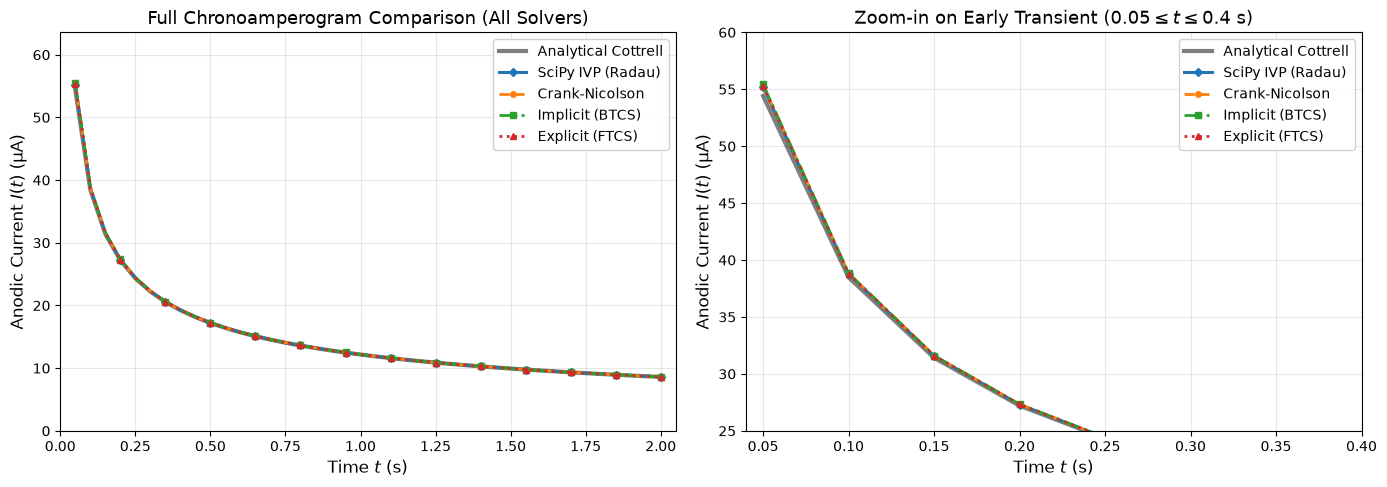

In [6]:
fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

styles = {
    "SciPy IVP (Radau)": {"color": "#1f77b4", "ls": "-", "lw": 2.2, "marker": "D", "ms": 4},
    "Crank-Nicolson":    {"color": "#ff7f0e", "ls": "--", "lw": 2.0, "marker": "o", "ms": 4},
    "Implicit (BTCS)":   {"color": "#2ca02c", "ls": "-.", "lw": 2.0, "marker": "s", "ms": 4},
    "Explicit (FTCS)":   {"color": "#d62728", "ls": ":",  "lw": 2.0, "marker": "^", "ms": 4},
}

# Main plot
ax_main.plot(times_nonzero, I_cottrell_uA, "k-", lw=3.0, alpha=0.5, label="Analytical Cottrell")
for name, res in results.items():
    I_num = -n * F * A * res.fluxes["Red"][1:] * 1e6
    st = styles[name]
    ax_main.plot(
        times_nonzero,
        I_num,
        label=name,
        color=st["color"],
        linestyle=st["ls"],
        linewidth=st["lw"],
        marker=st["marker"],
        markersize=st["ms"],
        markevery=3
    )

ax_main.set_xlabel("Time $t$ (s)")
ax_main.set_ylabel("Anodic Current $I(t)$ (µA)")
ax_main.set_title("Full Chronoamperogram Comparison (All Solvers)")
ax_main.set_xlim(0, 2.05)
ax_main.set_ylim(0, max(I_cottrell_uA[0], I_num[0]) * 1.15)
ax_main.legend(framealpha=0.9)

# Zoom-in on early transient (0.05 to 0.4 s)
ax_zoom.plot(times_nonzero, I_cottrell_uA, "k-", lw=3.0, alpha=0.5, label="Analytical Cottrell")
for name, res in results.items():
    I_num = -n * F * A * res.fluxes["Red"][1:] * 1e6
    st = styles[name]
    ax_zoom.plot(
        times_nonzero,
        I_num,
        label=name,
        color=st["color"],
        linestyle=st["ls"],
        linewidth=st["lw"],
        marker=st["marker"],
        markersize=st["ms"]
    )

ax_zoom.set_xlabel("Time $t$ (s)")
ax_zoom.set_ylabel("Anodic Current $I(t)$ (µA)")
ax_zoom.set_title(r"Zoom-in on Early Transient ($0.05 \leq t \leq 0.4$ s)")
ax_zoom.set_xlim(0.04, 0.4)
ax_zoom.set_ylim(25, 60)
ax_zoom.legend(framealpha=0.9)

plt.tight_layout()
plt.show()


---

## 4. Numerical Issues in Electrochemical Modeling

While all solvers yield accurate current curves when suitably configured, each engine embodies distinct mathematical properties regarding **stability**, **early-time step shocks**, and **computational efficiency**.

---

### Issue 1: Stability & The CFL Barrier for Explicit Solvers

In explicit finite differences (Forward-Time Central-Space / FTCS), the future concentration $c_i^{n+1}$ is computed entirely from existing values at time level $n$:

$$c_i^{n+1} = c_i^n + \frac{D \Delta t}{\Delta x^2} \left( c_{i+1}^n - 2c_i^n + c_{i-1}^n \right)$$

Von Neumann stability analysis proves that this explicit marching is numerically stable if and only if the **Courant-Friedrichs-Lewy (CFL)** condition is satisfied:

$$\Delta t \le \Delta t_{\text{CFL}} = \frac{\Delta x^2}{2 D}$$

If $\Delta t > \Delta t_{\text{CFL}}$, spatial truncation errors are magnified exponentially at every time step, producing catastrophic unphysical oscillations and numerical overflow (`NaN` / `Inf`).

#### Why does the CFL condition hurt electrochemists?
Electrochemists often need very fine spatial grids near the electrode ($\Delta x \le 1\,\mu\text{m}$) to resolve thin diffusion layers or rapid chemical kinetics. Because $\Delta t_{\text{CFL}} \propto \Delta x^2$:
- On our grid ($\Delta x = 2.0\,\mu\text{m}$, $D = 10^{-5}\text{ cm}^2/\text{s}$):
  $$\Delta t_{\text{CFL}} = \frac{(2.0 \times 10^{-4}\text{ cm})^2}{2 \times 10^{-5}\text{ cm}^2/\text{s}} = 2.0 \times 10^{-3}\text{ s} = 2.0\text{ ms}$$
  To simulate $2\text{ s}$, the explicit solver must take **at least 1,000 time steps**.
- If we refine the grid to $\Delta x = 0.5\,\mu\text{m}$, $\Delta t_{\text{CFL}}$ drops to $0.125\text{ ms}$, demanding **over 16,000 time steps**!

In contrast, implicit solvers (`implicit`, `crank_nicolson`, `scipy_ivp`) are **unconditionally stable**—they will never explode, regardless of how large $\Delta t$ is chosen!


In [7]:
# Calculate theoretical CFL limit
cfl_limit = (dx**2) / (2.0 * D)
print(f"CFL stability limit for dt: {cfl_limit:.4e} s ({cfl_limit*1000:.2f} ms)")

# Attempting to run Explicit solver with dt > CFL limit
unsafe_dt = 0.005  # 5 ms > 2 ms
print(f"Attempting to run Explicit solver with dt = {unsafe_dt*1000:.1f} ms...")

try:
    bad_explicit = ExplicitFiniteDifference(dt=unsafe_dt)
    bad_explicit.solve(problem, t_span=(0.0, 0.1))
except ValueError as e:
    print(f"\n[Safeguard Triggered]: Soft Potato automatically caught the instability!")
    print(f"Error message: {e}")

# Conversely, Implicit and Crank-Nicolson can easily take dt = 25 ms without instability:
print("\nRunning unconditionally stable Implicit solver with dt = 25.0 ms (>12x CFL limit)...")
safe_implicit = get_solver("implicit", dt=0.025)
res_large_dt = safe_implicit.solve(problem, t_span=(0.0, 0.5))
print(f"Implicit solver success: {res_large_dt.success} | Final flux: {res_large_dt.fluxes['Red'][-1]:.4e}")


CFL stability limit for dt: 2.0000e-03 s (2.00 ms)
Attempting to run Explicit solver with dt = 5.0 ms...

[Safeguard Triggered]: Soft Potato automatically caught the instability!
Error message: Specified time step dt=5.000e-03 exceeds the CFL stability limit dx²/(2*D_max)=2.000e-03.

Running unconditionally stable Implicit solver with dt = 25.0 ms (>12x CFL limit)...
Implicit solver success: True | Final flux: -2.5656e-09


---

### Issue 2: Early-Time Discontinuities & Crank-Nicolson Oscillations

Chronoamperometry features an intrinsic mathematical **discontinuity at $t = 0$**:
- For $t = 0$: $c_{\text{Red}}(x) = c^*$ everywhere, including at the electrode surface $x = 0$.
- For $t > 0$: $c_{\text{Red}}(0) = 0$ instantaneously.

This infinite gradient jump at $(x=0, t=0)$ interacts differently with the numerical damping properties of each solver:

1. **Crank-Nicolson (Trapezoidal)**:
   Crank-Nicolson is 2nd-order accurate and **A-stable**, but **not L-stable**. Its numerical damping factor approaches $-1$ for large high-frequency spatial modes. When subjected to a step discontinuity, Crank-Nicolson can produce high-frequency numerical oscillations (known as the **Rannacher effect**) if the initial time step $\Delta t$ is too large.
2. **Implicit BTCS**:
   Backward-Time Central-Space is only 1st-order accurate, but it is **L-stable** (damping factor approaches $0$ as $\Delta t \to \infty$). It strongly damps all high-frequency perturbations, ensuring strictly **monotonic, non-oscillatory decay** even for large time steps.
3. **SciPy IVP (Radau)**:
   Radau IIA is a 5th-order implicit Runge-Kutta method that is fully **L-stable** and features **adaptive time-stepping**. Near $t = 0$, it automatically takes microsecond sub-steps to resolve the initial gradient shock smoothly, then seamlessly broadens its time step as the profile smooths out.

Let us demonstrate this phenomenon by intentionally using a coarse time step ($\Delta t = 25\text{ ms}$).


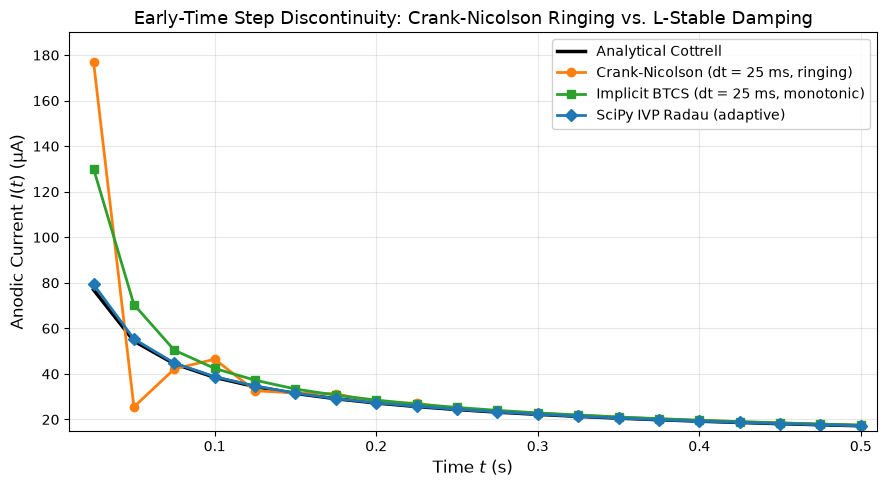

In [8]:
# Test with a coarse time step: dt = 25 ms
dt_coarse = 0.025
t_eval_coarse = np.arange(0.0, 0.5 + dt_coarse, dt_coarse)

res_cn_coarse = get_solver("crank_nicolson", dt=dt_coarse).solve(problem, t_span=(0.0, 0.5), t_eval=t_eval_coarse)
res_btcs_coarse = get_solver("implicit", dt=dt_coarse).solve(problem, t_span=(0.0, 0.5), t_eval=t_eval_coarse)
res_radau_adapt = get_solver("scipy_ivp", method="Radau").solve(problem, t_span=(0.0, 0.5), t_eval=t_eval_coarse)

I_cn_coarse = -n * F * A * res_cn_coarse.fluxes["Red"][1:] * 1e6
I_btcs_coarse = -n * F * A * res_btcs_coarse.fluxes["Red"][1:] * 1e6
I_radau_adapt = -n * F * A * res_radau_adapt.fluxes["Red"][1:] * 1e6
I_ana_coarse = (n * F * A * np.sqrt(D) * c_bulk / np.sqrt(np.pi * t_eval_coarse[1:])) * 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_eval_coarse[1:], I_ana_coarse, "k-", lw=2.5, label="Analytical Cottrell")
ax.plot(t_eval_coarse[1:], I_cn_coarse, "o-", color="#ff7f0e", lw=2, label="Crank-Nicolson (dt = 25 ms, ringing)")
ax.plot(t_eval_coarse[1:], I_btcs_coarse, "s-", color="#2ca02c", lw=2, label="Implicit BTCS (dt = 25 ms, monotonic)")
ax.plot(t_eval_coarse[1:], I_radau_adapt, "D-", color="#1f77b4", lw=2, label="SciPy IVP Radau (adaptive)")

ax.set_xlabel("Time $t$ (s)")
ax.set_ylabel("Anodic Current $I(t)$ (µA)")
ax.set_title("Early-Time Step Discontinuity: Crank-Nicolson Ringing vs. L-Stable Damping")
ax.set_xlim(0.01, 0.51)
ax.set_ylim(15, 190)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()


---

### Issue 3: Error Analysis & Spatial Convergence

How accurate are the simulated currents compared to the true analytical Cottrell solution?

We define the percentage relative error at each sampled time point:

$$\% \text{ Relative Error}(t) = \frac{\left| I_{\text{num}}(t) - I_{\text{Cottrell}}(t) \right|}{I_{\text{Cottrell}}(t)} \times 100\%$$

Below, we compute this error across all solvers, and perform a **spatial grid convergence study** to determine how grid refinement ($\Delta x \to 0$) improves the accuracy of the computed surface gradient.


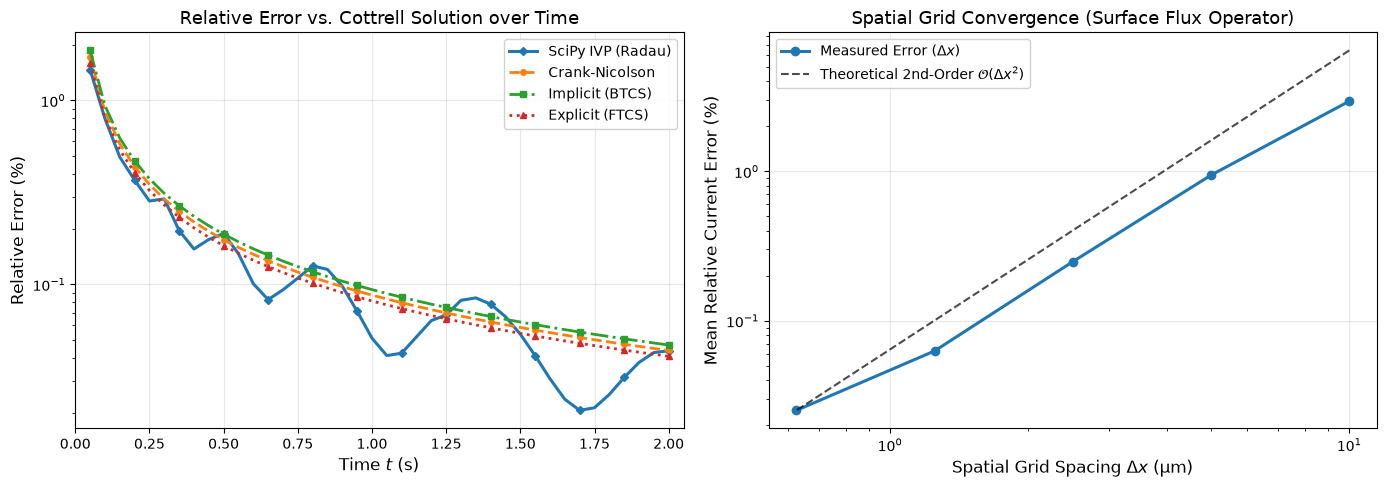

In [9]:
fig, (ax_err_time, ax_err_grid) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Relative Error vs. Time ---
for name, res in results.items():
    I_num = -n * F * A * res.fluxes["Red"][1:] * 1e6
    rel_err = np.abs(I_num - I_cottrell_uA) / I_cottrell_uA * 100
    st = styles[name]
    ax_err_time.plot(
        times_nonzero,
        rel_err,
        label=name,
        color=st["color"],
        linestyle=st["ls"],
        linewidth=st["lw"],
        marker=st["marker"],
        markersize=st["ms"],
        markevery=3
    )

ax_err_time.set_xlabel("Time $t$ (s)")
ax_err_time.set_ylabel("Relative Error (%)")
ax_err_time.set_title("Relative Error vs. Cottrell Solution over Time")
ax_err_time.set_xlim(0, 2.05)
ax_err_time.set_yscale("log")
ax_err_time.legend(framealpha=0.9)

# --- Panel 2: Spatial Grid Convergence Study ---
# Test grid sizes Nx = 51, 101, 201, 401, 801 (dx from 10 um down to 0.6 um)
grid_sizes = [51, 101, 201, 401, 801]
dx_values = []
mean_errors = []

for Nx_i in grid_sizes:
    x_i = np.linspace(0.0, L, Nx_i)
    dx_i = x_i[1] - x_i[0]
    dx_values.append(dx_i * 1e4)  # convert to um
    
    prob_i = DiffusionProblem(
        grid=x_i,
        diffusivity={"Red": D},
        boundary_conditions={"Red": (DirichletBC(0.0), DirichletBC(c_bulk))},
        initial_conditions={"Red": c_bulk},
    )
    res_i = get_solver("scipy_ivp", method="Radau", rtol=1e-7, atol=1e-9).solve(
        prob_i, t_span=(t_start, t_end), t_eval=t_eval
    )
    I_num_i = -n * F * A * res_i.fluxes["Red"][1:] * 1e6
    err_i = np.mean(np.abs(I_num_i - I_cottrell_uA) / I_cottrell_uA) * 100
    mean_errors.append(err_i)

ax_err_grid.loglog(dx_values, mean_errors, "o-", color="#1f77b4", lw=2.2, label=r"Measured Error ($\Delta x$)")
# Second-order reference slope O(dx²)
dx_ref = np.array(dx_values)
ref_line = mean_errors[-1] * (dx_ref / dx_ref[-1])**2
ax_err_grid.loglog(dx_ref, ref_line, "k--", lw=1.5, alpha=0.7, label=r"Theoretical 2nd-Order $\mathcal{O}(\Delta x^2)$")

ax_err_grid.set_xlabel(r"Spatial Grid Spacing $\Delta x$ (µm)")
ax_err_grid.set_ylabel("Mean Relative Current Error (%)")
ax_err_grid.set_title("Spatial Grid Convergence (Surface Flux Operator)")
ax_err_grid.legend(framealpha=0.9)

plt.tight_layout()
plt.show()


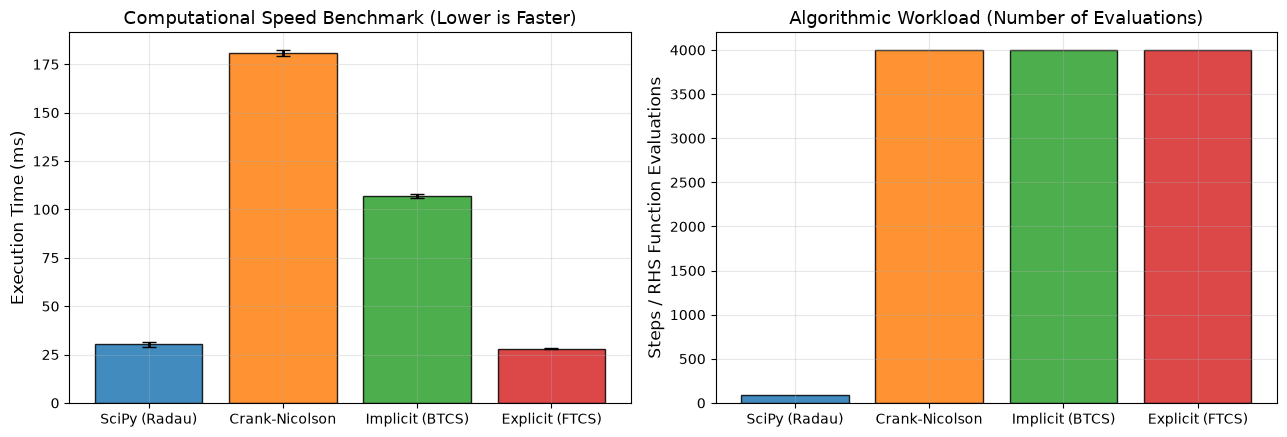

In [10]:
# Accurate execution timing over 5 repeated runs
n_repeats = 5
bench_times = {name: [] for name in solvers}

for _ in range(n_repeats):
    for name, solver in solvers.items():
        t0 = time.perf_counter()
        solver.solve(problem, t_span=(t_start, t_end), t_eval=t_eval)
        bench_times[name].append((time.perf_counter() - t0) * 1000)

avg_times = [np.mean(bench_times[name]) for name in solvers]
std_times = [np.std(bench_times[name]) for name in solvers]

# Internal steps / evaluations count
steps_count = [
    results["SciPy IVP (Radau)"].raw_output.nfev,  # Number of RHS evaluations
    int((t_end - t_start) / dt_step),              # Crank-Nicolson steps
    int((t_end - t_start) / dt_step),              # Implicit steps
    int((t_end - t_start) / dt_step),              # Explicit steps
]

fig, (ax_time, ax_steps) = plt.subplots(1, 2, figsize=(13, 4.5))

solver_labels = ["SciPy (Radau)", "Crank-Nicolson", "Implicit (BTCS)", "Explicit (FTCS)"]
colors_bar = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

ax_time.bar(solver_labels, avg_times, yerr=std_times, capsize=5, color=colors_bar, alpha=0.85, edgecolor="black")
ax_time.set_ylabel("Execution Time (ms)")
ax_time.set_title("Computational Speed Benchmark (Lower is Faster)")

ax_steps.bar(solver_labels, steps_count, color=colors_bar, alpha=0.85, edgecolor="black")
ax_steps.set_ylabel("Steps / RHS Function Evaluations")
ax_steps.set_title("Algorithmic Workload (Number of Evaluations)")

plt.tight_layout()
plt.show()


---

## 5. Summary & Solver Selection Guide for Electrochemists

### Performance and Characteristic Matrix

| Solver Engine | Temporal Accuracy | Stability Status | Initial Shock Damping | Efficiency | Recommended Electrochemical Applications |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`crank_nicolson`** | $\mathcal{O}(\Delta t^2)$ (2nd order) | Unconditionally Stable | May ring if $\Delta t$ is coarse | **Very Fast** (tridiagonal $\mathcal{O}(N)$) | Smooth potential sweeps, cyclic voltammetry (CV), linear sweep voltammetry (LSV), AC voltammetry. |
| **`implicit`** (BTCS) | $\mathcal{O}(\Delta t)$ (1st order) | Unconditionally Stable | Strictly monotonic (L-stable) | **Very Fast** (tridiagonal $\mathcal{O}(N)$) | Chronoamperometry with large time steps, steep potential steps, non-oscillatory baseline simulations. |
| **`scipy_ivp`** (Radau) | High-order adaptive | Unconditionally Stable (L-stable) | Smooth adaptive resolution | **Moderate** | Complex homogeneous chemical kinetics (EC, EC', ECE mechanisms), non-linear reaction rates, multi-species coupling. |
| **`explicit`** (FTCS) | $\mathcal{O}(\Delta t)$ (1st order) | Conditionally Stable ($\Delta t \le \frac{\Delta x^2}{2 D}$) | N/A (must satisfy CFL) | **Slow on fine meshes** | Educational demonstrations, quick sanity tests on coarse grids. |

---

### Practical Rules of Thumb for Modeling Diffusion in Electrochemistry

1. **Domain Length Sizing ($L$)**:
   Always check the diffusion penetration depth before starting:
   $$L \ge 6 \sqrt{D t_{\text{max}}}$$
   Setting $L$ smaller than this will cause the diffusion layer to hit the outer boundary, producing false steady-state currents or boundary reflection artifacts.

2. **Spatial Grid Discretization ($\Delta x$)**:
   To capture the initial transient accurately, the spatial grid size $\Delta x$ should be smaller than the diffusion layer at your first recorded time point $t_{\text{min}}$:
   $$\Delta x \le \frac{\sqrt{\pi D t_{\text{min}}}}{5}$$
   Because Soft Potato evaluates surface flux using a 2nd-order finite difference stencil, reducing $\Delta x$ decreases the current error quadratically ($\mathcal{O}(\Delta x^2)$).

3. **Time Stepping Strategy**:
   - For fast, accurate cyclic voltammetry, choose `crank_nicolson`.
   - For chronoamperometry with sharp initial steps, use `scipy_ivp` (Radau) or `implicit` (BTCS) to avoid unphysical numerical ringing at short times.
   - If modeling homogeneous chemical reactions with very fast rate constants ($k > 10^4\text{ s}^{-1}$), always select `scipy_ivp` (Radau) to handle the resulting mathematical stiffness.
